<a href="https://colab.research.google.com/github/loki112106/leukemia-detection-model-training/blob/main/leukemia_detection_program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
tf.__version__

'2.19.0'

In [ ]:
!pip install scikit-image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
import os
import ssl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  # linear algebra
import tensorflow as tf

ssl._create_default_https_context = ssl._create_unverified_context
from skimage import io, filters, color, segmentation
from skimage.transform import rescale, resize, downscale_local_mean, rotate
from tensorflow.keras import losses, models, optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Convolution2D, Dense, Dropout, GlobalAveragePooling2D,
                          GlobalMaxPool2D, Input, MaxPool2D, concatenate, Activation,
                          MaxPooling2D, Flatten, BatchNormalization, Conv2D, AveragePooling2D)
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, multilabel_confusion_matrix
from tensorflow.keras.metrics import binary_accuracy
from sklearn.model_selection import StratifiedShuffleSplit
from tensorflow.keras import regularizers

In [ ]:
# Image size
fftn = 150
fftm = 150

# data preparation, reading labels: sick - 'all' or 1, healthy - 'hem' or 0
def preproc_resize(img):
    new_img = img
    new_img = resize(img, (fftn, fftm, 3), anti_aliasing=True)
    return new_img

path = "/content/drive/MyDrive/leukovision"
image_list = []
label = []
path_list = [path + '/fold_0', path + '/fold_1', path + '/fold_2']

for i in path_list:
    dirr_all = i + '/' + 'all'
    dirr_hem = i + '/' + 'hem'

    listdir_all = os.listdir(dirr_all)
    listdir_hem = os.listdir(dirr_hem)

    for j in listdir_all:
        image_list.append(dirr_all + '/' + j)
        label.append(1)
    for j in listdir_hem:
        image_list.append(dirr_hem + '/' + j)
        label.append(0)

In [ ]:
df = pd.DataFrame(list(zip(image_list, label)), columns=['Img', 'label'])

In [ ]:
df['Img']

,Img
0,/content/drive/MyDrive/leukovision/fold_0/all/...
1,/content/drive/MyDrive/leukovision/fold_0/all/...
2,/content/drive/MyDrive/leukovision/fold_0/all/...
3,/content/drive/MyDrive/leukovision/fold_0/all/...
4,/content/drive/MyDrive/leukovision/fold_0/all/...
...,...
10656,/content/drive/MyDrive/leukovision/fold_2/hem/...
10657,/content/drive/MyDrive/leukovision/fold_2/hem/...
10658,/content/drive/MyDrive/leukovision/fold_2/hem/...
10659,/content/drive/MyDrive/leukovision/fold_2/hem/...


In [ ]:
df['label']

,label
0,1
1,1
2,1
3,1
4,1
...,...
10656,0
10657,0
10658,0
10659,0


In [ ]:
print(df)

                                                     Img  label
0      /content/drive/MyDrive/leukovision/fold_0/all/...      1
1      /content/drive/MyDrive/leukovision/fold_0/all/...      1
2      /content/drive/MyDrive/leukovision/fold_0/all/...      1
3      /content/drive/MyDrive/leukovision/fold_0/all/...      1
4      /content/drive/MyDrive/leukovision/fold_0/all/...      1
...                                                  ...    ...
10656  /content/drive/MyDrive/leukovision/fold_2/hem/...      0
10657  /content/drive/MyDrive/leukovision/fold_2/hem/...      0
10658  /content/drive/MyDrive/leukovision/fold_2/hem/...      0
10659  /content/drive/MyDrive/leukovision/fold_2/hem/...      0
10660  /content/drive/MyDrive/leukovision/fold_2/hem/...      0

[10661 rows x 2 columns]


In [ ]:
img = io.imread("/content/drive/MyDrive/leukovision/fold_0/all/UID_11_10_1_all.bmp")
new_img = resize(img, (fftn, fftm, 3), anti_aliasing=True)
x = np.empty(shape=(1, fftn, fftm, 3))
x[0,] = new_img

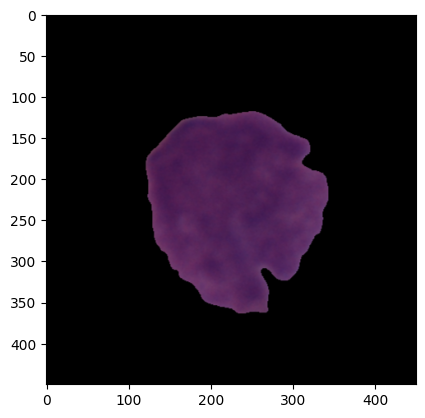

In [ ]:
plt.imshow(img)

In [ ]:
# Splitting data into test and training datasets
split = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)

for train_index, test_index in split.split(df, df["label"]):
    strat_train = df.loc[train_index]
    strat_test = df.loc[test_index]

xTrain = np.empty(shape=(len(strat_train), fftn, fftm, 3))
xTest = np.empty(shape=(len(strat_test), fftn, fftm, 3))

yTrain = np.empty(shape=(len(strat_train), 2))
yTest = np.empty(shape=(len(strat_test), 2))

print(len(xTrain))
print(len(xTest))
print(len(yTrain))
print(len(yTest))

train_count = 0
test_count = 0

for i in list(strat_train.index):
    img = preproc_resize(io.imread(strat_train['Img'][i]))
    xTrain[train_count, ] = img
    if strat_train['label'][i] == 1:
        yTrain[train_count, ] = [0, 1]
    if strat_train['label'][i] == 0:
        yTrain[train_count, ] = [1, 0]
    train_count += 1

plt.title('Amount of ill people on train data set')
plt.ylabel('Amount')
strat_train['label'].value_counts().plot(kind='bar')
plt.show()

for i in list(strat_test.index):
    img = preproc_resize(io.imread(strat_test['Img'][i]))
    xTest[test_count,] = img
    if strat_test['label'][i] == 1:
        yTest[test_count,] = [0, 1]
    if strat_test['label'][i] == 0:
        yTest[test_count,] = [1, 0]
    test_count += 1


plt.title('Amount of ill people on test data set')
plt.ylabel('Amount')
strat_test['label'].value_counts().plot(kind='bar')
plt.show()

6396
4265
6396
4265


KeyboardInterrupt: 

In [ ]:
# neural network model
kernel_initializer = 'lecun_uniform'
bias_initializer = 'lecun_uniform'
kernel_regularizer = None
activation = "selu"

batch_size = 8
data_rows = fftn
data_cols = fftm
input_shape = (data_rows, data_cols, 3)

# learning epochs
nb_epoch = 35
# learning rate
alpha_zero = 0.001

model = models.Sequential()
model.add(Conv2D(32, (3, 3), input_shape=input_shape, data_format="channels_last", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=kernel_regularizer))
model.add(Activation(activation))
model.add(MaxPooling2D(pool_size=(3, 3)))

model.add(Conv2D(64, (3, 3), input_shape=input_shape, data_format="channels_last", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=kernel_regularizer))
model.add(Activation(activation))
model.add(MaxPooling2D(pool_size=(3, 3)))

model.add(Conv2D(128, (3, 3), input_shape=input_shape, data_format="channels_last", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=kernel_regularizer))
model.add(Activation(activation))
model.add(MaxPooling2D(pool_size=(3, 3)))

model.add(Conv2D(256, (3, 3), input_shape=input_shape, data_format="channels_last", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=kernel_regularizer))
model.add(Activation(activation))
model.add(Dropout(0.8))

# adding connected layers
model.add(Flatten())
model.add(Dense(256, kernel_initializer=kernel_initializer, bias_initializer=bias_initializer))
model.add(Activation(activation))
model.add(Dropout(0.8))
model.add(Dense(128, kernel_initializer=kernel_initializer, bias_initializer=bias_initializer))
model.add(Activation(activation))
model.add(Dropout(0.8))
model.add(Dense(64, kernel_initializer=kernel_initializer, bias_initializer=bias_initializer))
model.add(Activation(activation))
model.add(Dropout(0.6))
model.add(Dense(32, kernel_initializer=kernel_initializer, bias_initializer=bias_initializer))

model.add(Dense(2))
model.add(Activation('sigmoid'))
model.summary()

model.compile(loss=["binary_crossentropy"], optimizer="adam", metrics=["accuracy"])
history = model.fit(xTrain, yTrain, epochs=nb_epoch, verbose=2, validation_data=(xTest, yTest), validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 2)              │             

 Total params: 694,114 (2.65 MB)

 Trainable params: 694,114 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35
200/200 - 208s - 1s/step - accuracy: 0.6159 - loss: 1.1652 - val_accuracy: 0.7742 - val_loss: 0.6002
Epoch 2/35
200/200 - 193s - 963ms/step - accuracy: 0.7086 - loss: 0.5904 - val_accuracy: 0.7986 - val_loss: 0.4649
Epoch 3/35
200/200 - 186s - 932ms/step - accuracy: 0.7558 - loss: 0.5361 - val_accuracy: 0.7927 - val_loss: 0.4812
Epoch 4/35
200/200 - 196s - 981ms/step - accuracy: 0.7636 - loss: 0.5351 - val_accuracy: 0.8045 - val_loss: 0.4624
Epoch 5/35
200/200 - 201s - 1s/step - accuracy: 0.7753 - loss: 0.5168 - val_accuracy: 0.8033 - val_loss: 0.4370
Epoch 6/35
200/200 - 197s - 986ms/step - accuracy: 0.7794 - loss: 0.5117 - val_accuracy: 0.8143 - val_loss: 0.4372
Epoch 7/35
200/200 - 197s - 987ms/step - accuracy: 0.7824 - loss: 0.5101 - val_accuracy: 0.8225 - val_loss: 0.4353
Epoch 8/35
200/200 - 190s - 952ms/step - accuracy: 0.7866 - loss: 0.5099 - val_accuracy: 0.8080 - val_loss: 0.4543
Epoch 9/35
200/200 - 198s - 990ms/step - accuracy: 0.7846 - loss: 0.4971 - val_accurac

In [ ]:
score = model.evaluate(xTest, yTest, verbose=0)
print("Accuracy: %f" % score[1])
yPred = model.predict(xTest)

Accuracy: 0.865885
134/134 ━━━━━━━━━━━━━━━━━━━━ 33s 241ms/step


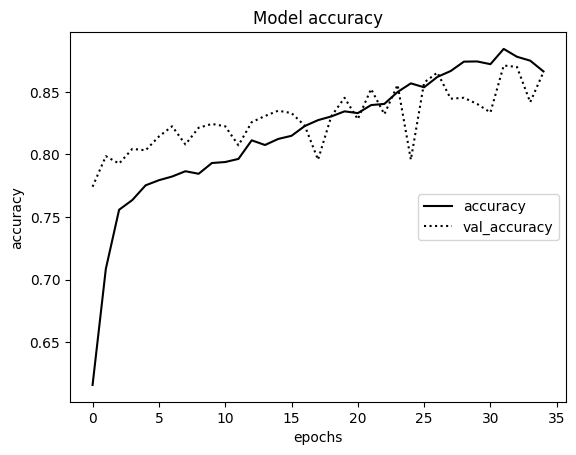

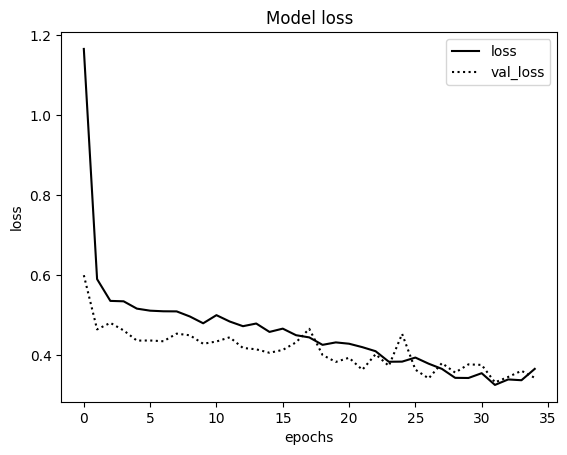

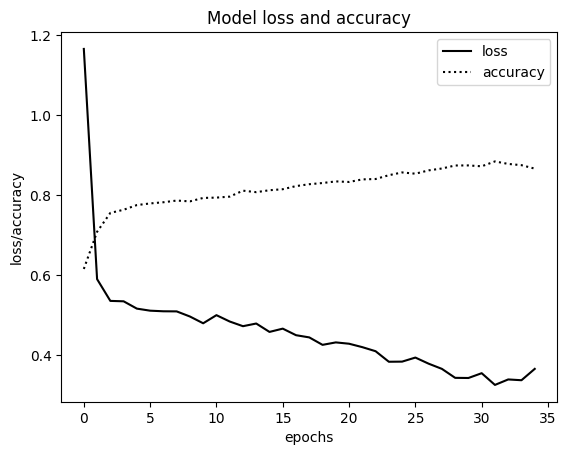

In [ ]:
def visualise(history):

    # summarize history for accuracy
    plt.plot(history.history['accuracy'], 'k-')
    plt.plot(history.history['val_accuracy'], 'k:')
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epochs')
    plt.legend(['accuracy', 'val_accuracy'], loc='center right')
    plt.show()
    # summarize history for loss
    plt.plot(history.history['loss'], 'k-')
    plt.plot(history.history['val_loss'], 'k:')
    plt.title('Model loss')
    plt.ylabel('loss')
    plt.xlabel('epochs')
    plt.legend(['loss', 'val_loss'], loc='upper right')
    plt.show()

    # summarize history for loss
    plt.plot(history.history['loss'], 'k')
    plt.plot(history.history['accuracy'], 'k:')
    plt.title('Model loss and accuracy')
    plt.ylabel('loss/accuracy')
    plt.xlabel('epochs')
    plt.legend(['loss', 'accuracy'], loc='upper right')
    plt.show()

# predict class for new image


visualise(history)

In [ ]:
def pred_image(model, image):
    img = io.imread(image)
    new_img = resize(img, (fftn, fftm, 3), anti_aliasing=True)
    x = np.empty(shape=(1, fftn, fftm, 3))
    x[0,] = new_img
    yPred = model.predict(x)
    print("*RESULT*")
    print(yPred)
    if yPred[0][0]>yPred[0][1]:
        print('Normal')
    else:
        print("Leukemia Affected")

In [ ]:
l = pred_image(model, df['Img'][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
*RESULT*
[[0.12675   0.8946891]]
Leukemia Affected


In [ ]:
pred_image(model, '/content/drive/MyDrive/leukovision/fold_0/hem/UID_H7_8_1_hem.bmp')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
*RESULT*
[[0.20782635 0.8239499 ]]
Leukemia Affected


In [ ]:
`pred_image(model, '/content/drive/MyDrive/leukovision/fold_1/all/UID_51_98_5_all.bmp')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
*RESULT*
[[0.11923925 0.903975  ]]
Leukemia Affected


In [ ]:
pred_image(model, '/content/drive/MyDrive/leukovision/fold_1/all/UID_51_98_5_all.bmp')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
*RESULT*
[[0.11923925 0.903975  ]]
Leukemia Affected
